# Clasificación automática de estadios del sueño mediante aprendizaje de máquina

**Análisis de datos — Sleep-EDF Database Expanded, subconjunto Sleep Cassette**

Universidad de los Andes — Maestría en Inteligencia Artificial

# 1. Lectura de datos

Se documenta la carga de los metadatos de los sujetos y de los registros de polisomnografía (PSG) con sus
hipnogramas correspondientes, para el subconjunto Sleep Cassette de la base de datos Sleep-EDF Database
Expanded (PhysioNet).

## 1.1 Librerías y configuración

In [1]:
import glob, os, warnings

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from scipy.signal import welch

mne.set_log_level("WARNING")
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Este notebook vive en EDA/Sebastian/, por lo que los datos están dos niveles arriba
DATA_DIR = "../../Data/sleep-cassette"
SUBJECTS_XLS = "../../Data/SC-subjects.xls"
CANAL = "EEG Fpz-Cz"

# Equivalencia entre la nomenclatura del hipnograma (Rechtschaffen & Kales) y los estadios AASM
ETAPAS = {"Sleep stage W": "W", "Sleep stage 1": "N1", "Sleep stage 2": "N2", "Sleep stage 3": "N3",
          "Sleep stage 4": "N3", "Sleep stage R": "REM", "Movement time": "M", "Sleep stage ?": "?"}
NREM = {"Sleep stage 2", "Sleep stage 3", "Sleep stage 4"}
COLOR = {"W": "#2a78d6", "N1": "#eb6834", "N2": "#1baf7a", "N3": "#eda100", "REM": "#e87ba4"}


## 1.2 Inventario de archivos

Cada noche registrada está compuesta por dos archivos EDF con un prefijo común: un registro de señal
(`*-PSG.edf`) y un hipnograma de anotaciones (`*-Hypnogram.edf`).

In [2]:
psg_files = sorted(glob.glob(DATA_DIR + "/*-PSG.edf"))
hyp_files = sorted(glob.glob(DATA_DIR + "/*-Hypnogram.edf"))

print("Registros PSG:", len(psg_files), "| Hipnogramas:", len(hyp_files))
print("Primer par:", os.path.basename(psg_files[0]), "->", os.path.basename(hyp_files[0]))


Registros PSG: 153 | Hipnogramas: 153
Primer par: SC4001E0-PSG.edf -> SC4001EC-Hypnogram.edf


## 1.3 Metadatos de los sujetos

Los metadatos de los sujetos (edad, sexo, número de noche, hora de apagado de luces) se encuentran en
`SC-subjects.xls`, con una fila por combinación sujeto-noche.

In [3]:
subjects = pd.read_excel(SUBJECTS_XLS).rename(columns={"sex (F=1)": "sex_code"})
subjects["sex"] = subjects["sex_code"].map({1: "F", 2: "M"})

print("Filas (sujeto-noche):", len(subjects), "| Sujetos únicos:", subjects["subject"].nunique())
subjects.head()


Filas (sujeto-noche): 153 | Sujetos únicos: 78


,subject,night,age,sex_code,LightsOff,sex
0,0,1,33,1,00:38:00,F
1,0,2,33,1,21:57:00,F
2,1,1,33,1,22:44:00,F
3,1,2,33,1,22:15:00,F
4,2,1,26,1,22:50:00,F


## 1.4 Lectura de un registro de señal (PSG)

Se ilustra la lectura de un registro mediante MNE-Python, tomando como ejemplo el primer archivo del
inventario.

In [4]:
raw = mne.io.read_raw_edf(psg_files[0], preload=True)

print("Archivo:   ", os.path.basename(psg_files[0]))
print("Canales:   ", raw.ch_names)
print("Frecuencia:", raw.info["sfreq"], "Hz")
print("Duración:  ", round(raw.n_times / raw.info["sfreq"] / 3600, 2), "horas")


Archivo:    SC4001E0-PSG.edf
Canales:    ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
Frecuencia: 100.0 Hz
Duración:   22.08 horas


## 1.5 Lectura del hipnograma

El hipnograma contiene una anotación por cada segmento de la noche, con su instante de inicio, duración y
etiqueta de estadio de sueño.

In [5]:
annotations = mne.read_annotations(hyp_files[0])
hypnogram = pd.DataFrame({"onset_s": annotations.onset, "duration_s": annotations.duration,
                          "stage": annotations.description})

print("Archivo:", os.path.basename(hyp_files[0]), "| Anotaciones:", len(hypnogram))
hypnogram.head()


Archivo: SC4001EC-Hypnogram.edf | Anotaciones: 154


,onset_s,duration_s,stage
0,0.0,30630.0,Sleep stage W
1,30630.0,120.0,Sleep stage 1
2,30750.0,390.0,Sleep stage 2
3,31140.0,30.0,Sleep stage 3
4,31170.0,30.0,Sleep stage 2


## 1.6 Construcción del dataset

Se consolidan las anotaciones de las 153 noches en una única tabla. Cada fila corresponde a un segmento
anotado del hipnograma (sujeto, noche, instante de inicio, duración y etapa), cruzado con la edad y el sexo
del sujeto. No se incluyen las señales, con el fin de mantener un tamaño manejable.

In [6]:
filas = []
for ruta_psg, ruta_hyp in zip(psg_files, hyp_files):
    nombre = os.path.basename(ruta_psg)  # SC4001E0-PSG.edf -> sujeto 00, noche 1
    ann = mne.read_annotations(ruta_hyp)
    filas += [{"subject": int(nombre[3:5]), "night": int(nombre[5]), "onset_s": onset,
               "duration_s": duracion, "stage": ETAPAS[etapa]}
              for onset, duracion, etapa in zip(ann.onset, ann.duration, ann.description)]

dataset = pd.DataFrame(filas).merge(subjects[["subject", "night", "age", "sex"]], on=["subject", "night"])

print("Filas del dataset:", len(dataset))
dataset.head()


Filas del dataset: 22430


,subject,night,onset_s,duration_s,stage,age,sex
0,0,1,0.0,30630.0,W,33,F
1,0,1,30630.0,120.0,N1,33,F
2,0,1,30750.0,390.0,N2,33,F
3,0,1,31140.0,30.0,N3,33,F
4,0,1,31170.0,30.0,N2,33,F


# 2. Calidad de los datos

Se verifica la integridad del dataset antes de describirlo: tipos de dato, valores faltantes y registros
duplicados.

## 2.1 Tipos de dato y valores nulos

In [7]:
print(dataset.dtypes, "\n")
print("Valores nulos por columna:")
print(dataset.isna().sum())


subject         int64
night           int64
onset_s       float64
duration_s    float64
stage          object
age             int64
sex            object
dtype: object 

Valores nulos por columna:
subject       0
night         0
onset_s       0
duration_s    0
stage         0
age           0
sex           0
dtype: int64


## 2.2 Valores duplicados

Que un sujeto pase por la misma etapa de sueño varias veces en una noche **no es un duplicado**: es normal
que aparezcan varios segmentos separados de N2 a lo largo de la noche. Solo se considera duplicado un
registro que coincide exactamente en sujeto, noche, instante de inicio, duración y etapa.

In [8]:
print("Filas duplicadas (exactas):", dataset.duplicated().sum())

Filas duplicadas (exactas): 0


# 3. Conteos y distribuciones

## 3.1 Sujetos: edad y sexo

Cada sujeto aparece hasta dos veces en `subjects` (una por noche), por lo que se toma una sola fila por
sujeto antes de describir su edad y sexo.

In [9]:
personas = subjects.drop_duplicates("subject")
print(f"Personas: {len(personas)} | {personas['sex'].value_counts().to_dict()} | "
      f"edad {personas['age'].min()}-{personas['age'].max()} años (media {personas['age'].mean():.0f})")

px.histogram(personas, x="age", nbins=15, title="Distribución de edad", labels={"age": "Edad"}
             ).update_layout(height=350, yaxis_title="Personas", bargap=0.05).show()

px.bar(personas["sex"].value_counts().rename_axis("Sexo").reset_index(name="Personas"),
       x="Sexo", y="Personas", title="Distribución de sexo").update_layout(height=350).show()


Personas: 78 | {'F': 41, 'M': 37} | edad 25-101 años (media 59)


## 3.2 Noches por paciente

El estudio registró **dos noches por paciente**, salvo unas pocas excepciones en las que un registro se
perdió. Esto explica la diferencia entre el número de personas y el número de registros disponibles, y es
un aspecto relevante para etapas posteriores: las dos noches de un mismo paciente no son observaciones
independientes.

In [10]:
noches_por_sujeto = dataset.groupby("subject")["night"].nunique()
conteo = noches_por_sujeto.value_counts().sort_index().rename_axis("Noches").reset_index(name="Pacientes")

print("Pacientes:", len(noches_por_sujeto), "| Registros:", dataset.groupby(["subject", "night"]).ngroups)
print(conteo.to_string(index=False))

print("\nPacientes que NO tienen las dos noches:")
incompletos = noches_por_sujeto[noches_por_sujeto < 2].index
print(subjects[subjects["subject"].isin(incompletos)][["subject", "night", "age", "sex"]].to_string(index=False))

px.bar(conteo, x="Noches", y="Pacientes", text="Pacientes", title="¿Cuántas noches tiene cada paciente?"
       ).update_layout(height=350, xaxis=dict(tickmode="array", tickvals=conteo["Noches"])).show()


Pacientes: 78 | Registros: 153
 Noches  Pacientes
      1          3
      2         75

Pacientes que NO tienen las dos noches:
 subject  night  age sex
      13      1   27   M
      36      2   51   M
      52      2   69   M


## 3.3 Cantidad de épocas por estadio

Se estima la cantidad de épocas de 30 segundos disponibles por etapa, sumando la duración de sus
anotaciones. La etiqueta `?` corresponde a épocas que el técnico no pudo clasificar y `M` a épocas con
exceso de movimiento.

In [11]:
segundos = dataset.groupby("stage")["duration_s"].sum().sort_values(ascending=False)
resumen_etapas = pd.DataFrame({"horas": segundos / 3600, "epocas_30s": round(segundos / 30)})
print(resumen_etapas)

tabla = resumen_etapas.rename_axis("Estadio").reset_index()
px.bar(tabla, x="Estadio", y="epocas_30s", title="Cantidad de datos por estadio (153 noches, sin recortar)",
       labels={"epocas_30s": "Épocas de 30 s"}).update_layout(height=380).show()


             horas  epocas_30s
stage                         
W      2382.808333    285937.0
N2      576.100000     69132.0
REM     215.291667     25835.0
?       208.725000     25047.0
N1      179.350000     21522.0
N3      108.658333     13039.0
M         1.066667       128.0


## 3.4 Épocas sin evaluar por noche

Se revisa qué proporción de cada registro quedó sin clasificar (`?`), lo que permite identificar noches
atípicas que podrían requerir revisión o exclusión en etapas posteriores.

In [12]:
horas_por_noche = dataset.pivot_table(index=["subject", "night"], columns="stage",
                                      values="duration_s", aggfunc="sum", fill_value=0) / 3600
pct_sin_evaluar = (horas_por_noche["?"] / horas_por_noche.sum(axis=1) * 100).rename("pct_sin_evaluar")

print(pct_sin_evaluar.describe().round(1).to_dict())
print("\nNoches con más del 20 % sin evaluar:")
print(pct_sin_evaluar[pct_sin_evaluar > 20].round(1).to_string())

px.histogram(pct_sin_evaluar.reset_index(), x="pct_sin_evaluar", nbins=30,
             title="Épocas sin clasificar por registro",
             labels={"pct_sin_evaluar": "% de la noche sin evaluar"}).update_layout(
    height=350, yaxis_title="Número de noches", bargap=0.05).show()


{'count': 153.0, 'mean': 5.7, 'std': 4.8, 'min': 0.0, '25%': 2.8, '50%': 4.5, '75%': 6.9, 'max': 29.2}

Noches con más del 20 % sin evaluar:
subject  night
9        2        28.6
49       2        25.8
59       2        29.2
77       2        22.2


# 4. Los 7 canales

Cada registro PSG contiene siete canales que miden fenómenos distintos del cuerpo durante el sueño:

| Canal | Qué mide |
|---|---|
| **EEG Fpz-Cz** | Actividad eléctrica del cerebro, con electrodo en la frente |
| **EEG Pz-Oz** | Actividad eléctrica del cerebro, con electrodo en la parte posterior de la cabeza |
| **EOG horizontal** | Movimiento de los ojos |
| **Resp oro-nasal** | Flujo de aire por la nariz y la boca, es decir, la respiración |
| **EMG submental** | Tensión del músculo de la barbilla |
| **Temp rectal** | Temperatura corporal |
| **Event marker** | Marcas del equipo de registro; no mide nada del cuerpo |

Los cuatro primeros son los relevantes para clasificar estadios de sueño: el cerebro, los ojos y el músculo
son precisamente las tres señales que un técnico observa para decidir en qué estadio se encuentra el sujeto.

## 4.1 Consistencia entre registros

In [13]:
cabeceras = [mne.io.read_raw_edf(ruta, preload=False).info for ruta in psg_files]

print("Combinaciones distintas de canales:", len({tuple(i["ch_names"]) for i in cabeceras}))
print("Frecuencias distintas:", {i["sfreq"] for i in cabeceras})

pd.DataFrame({"canal": raw.ch_names,
              "frecuencia_real_hz": [n / 30 for n in raw._raw_extras[0]["n_samps"]]})


Combinaciones distintas de canales: 1
Frecuencias distintas: {100.0}


,canal,frecuencia_real_hz
0,EEG Fpz-Cz,100.0
1,EEG Pz-Oz,100.0
2,EOG horizontal,100.0
3,Resp oro-nasal,1.0
4,EMG submental,1.0
5,Temp rectal,1.0
6,Event marker,1.0


Los 153 registros son idénticos en cuanto a canales y frecuencia. Sin embargo, aunque MNE reporta
100 Hz para todos, el encabezado del archivo EDF indica que **solo el EEG y el EOG se registraron realmente a
100 Hz**; la respiración, el EMG y la temperatura están a 1 Hz.

## 4.2 Cómo se ve cada canal

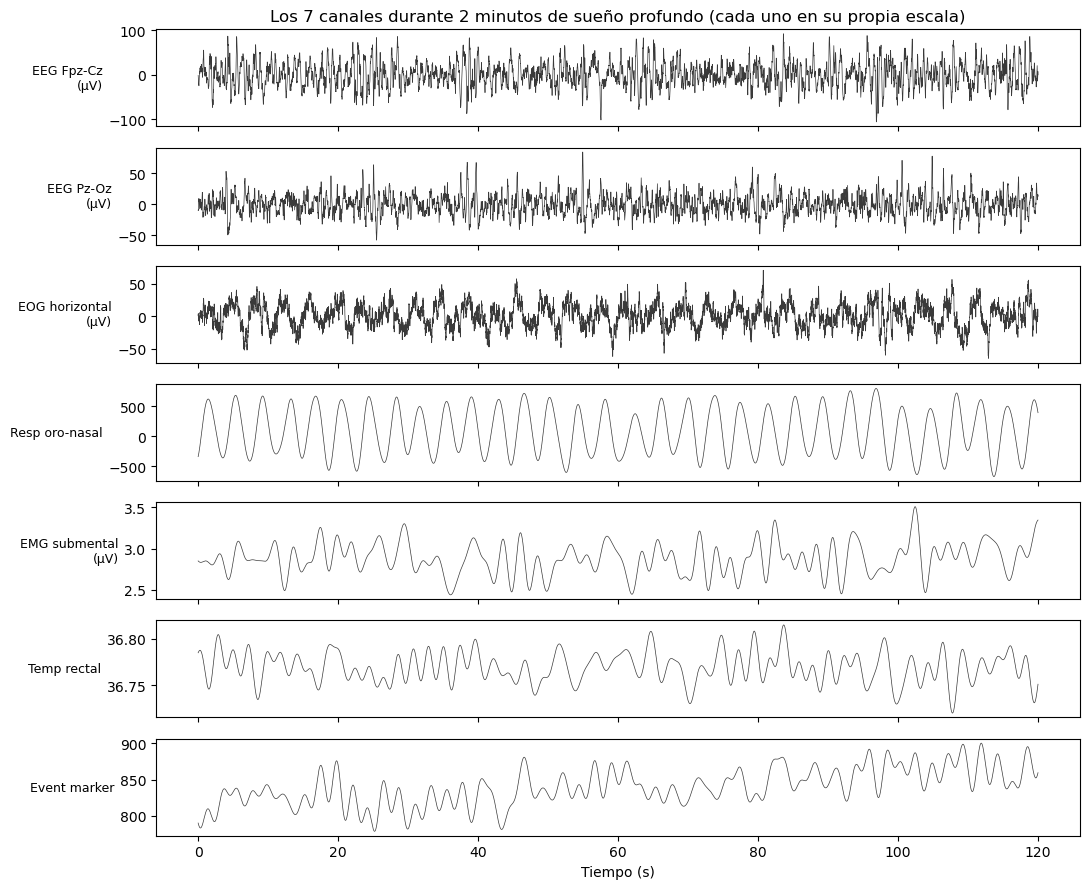

In [14]:
fs = raw.info["sfreq"]
inicio = hypnogram[hypnogram["stage"] == "Sleep stage 4"]["onset_s"].iloc[0]  # sueño profundo
datos, t = raw.get_data(start=int(inicio * fs), stop=int((inicio + 120) * fs), return_times=True)

fig, ejes = plt.subplots(7, 1, figsize=(11, 9), sharex=True)
for señal_canal, nombre, eje in zip(datos, raw.ch_names, ejes):
    electrico = any(tipo in nombre for tipo in ("EEG", "EOG", "EMG"))
    eje.plot(t - t[0], señal_canal * 1e6 if electrico else señal_canal, linewidth=0.5, color="#3a3a3a")
    eje.set_ylabel(nombre + ("\n(µV)" if electrico else ""), rotation=0, ha="right", va="center", fontsize=9)

ejes[0].set_title("Los 7 canales durante 2 minutos de sueño profundo (cada uno en su propia escala)")
ejes[-1].set_xlabel("Tiempo (s)")
plt.tight_layout()
plt.show()


# 5. Selección del canal de trabajo

De aquí en adelante se trabaja únicamente con **EEG Fpz-Cz**, por tres razones:

1. Es el canal utilizado como referencia en la literatura sobre esta base de datos (DeepSleepNet,
   TinySleepNet, SleepEEGNet), lo que permite comparar resultados.
2. Es uno de los tres canales registrados realmente a 100 Hz.
3. Un único canal simplifica la visualización y reduce los requisitos de entrada del sistema final.

Se presenta a continuación junto con el estadio de sueño correspondiente, mediante un gráfico interactivo con
control deslizante. Una noche completa supera los 7 millones de muestras, por lo que la visualización se
limita a una ventana de 2 horas desde el inicio del sueño, con la señal decimada por un factor de 16.

In [15]:
inicio_sueño = hypnogram[hypnogram["stage"] != "Sleep stage W"]["onset_s"].iloc[0]
t_inicio, t_fin = inicio_sueño - 60, inicio_sueño + 2 * 3600

señal, tiempos = raw.get_data(picks=[CANAL], start=int(t_inicio * fs), stop=int(t_fin * fs),
                              return_times=True)

fig = go.Figure(go.Scatter(x=tiempos[::16] / 3600, y=señal[0][::16] * 1e6, mode="lines",
                           line=dict(width=1, color="#3a3a3a"), showlegend=False))

# Franjas de color de fondo según el estadio de sueño
ventana = hypnogram[(hypnogram["onset_s"] + hypnogram["duration_s"] > t_inicio) & (hypnogram["onset_s"] < t_fin)]
for _, fila in ventana.iterrows():
    fig.add_vrect(x0=max(fila["onset_s"], t_inicio) / 3600,
                  x1=min(fila["onset_s"] + fila["duration_s"], t_fin) / 3600,
                  fillcolor=COLOR.get(ETAPAS[fila["stage"]], "#999999"), opacity=0.25, line_width=0)

for etapa, color in COLOR.items():  # leyenda
    fig.add_scatter(x=[None], y=[None], mode="markers", marker=dict(size=10, color=color), name=etapa)

fig.update_layout(height=420, legend_title_text="Estadio", margin=dict(t=30, b=10),
                  yaxis_title=f"{CANAL} (µV)",
                  xaxis=dict(title="Tiempo (horas)", rangeslider_visible=True))
fig.show()


# 6. Actividad cerebral según la edad del sujeto

Se evalúa si el contenido de la señal varía entre sujetos de distinta edad. Para ello la señal se descompone
en sus componentes de frecuencia mediante la transformada de Fourier (método de Welch), lo que permite
cuantificar cuánta actividad presenta el cerebro en cada rango de velocidad de onda.

El procedimiento se aplica a las 153 noches: de cada una se toman 30 épocas de 30 segundos de sueño NREM
distribuidas a lo largo de la noche, y se promedia el espectro resultante.

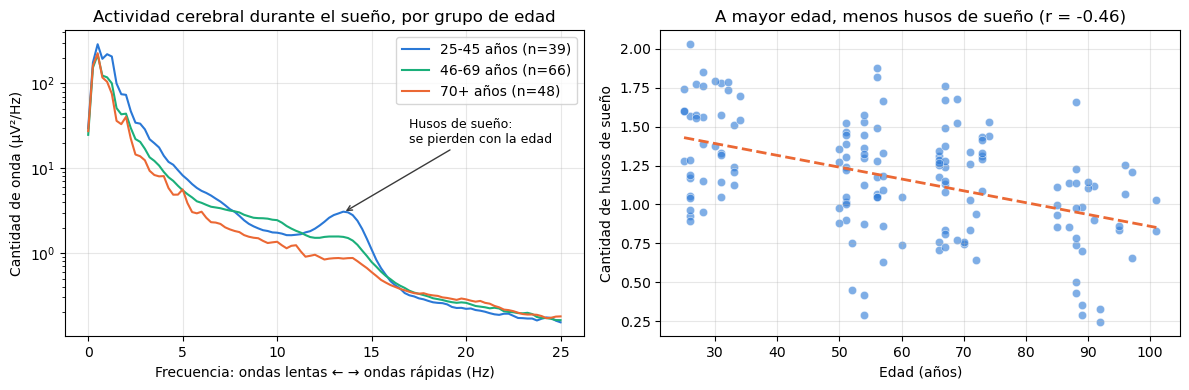

In [16]:
GRUPOS = {"25-45 años": (25, 45, "#2a78d6"), "46-69 años": (46, 69, "#1baf7a"),
          "70+ años": (70, 120, "#eb6834")}


def espectro_de_la_noche(ruta_psg, ruta_hyp, n_epocas=30):
    """Espectro promedio de n_epocas de sueño NREM repartidas a lo largo de una noche."""
    ann = mne.read_annotations(ruta_hyp)
    registro = mne.io.read_raw_edf(ruta_psg, preload=False)
    frec = registro.info["sfreq"]
    inicios = [onset + 30 * k for onset, duracion, etapa in zip(ann.onset, ann.duration, ann.description)
               if etapa in NREM for k in range(int(duracion // 30))]

    psds = []
    for i in np.linspace(0, len(inicios) - 1, n_epocas).astype(int):
        ini = int(inicios[i] * frec)
        muestras = registro.get_data(picks=[CANAL], start=ini, stop=ini + int(30 * frec))[0]
        frecuencias, psd = welch(muestras, fs=frec, nperseg=int(4 * frec))
        psds.append(psd)
    return frecuencias, np.mean(psds, axis=0) * 1e12  # V²/Hz -> µV²/Hz


# Espectro de cada una de las 153 noches (~45 s) y edad del sujeto correspondiente
resultados = [espectro_de_la_noche(p, h) for p, h in zip(psg_files, hyp_files)]
frecs, espectros = resultados[0][0], np.array([e for _, e in resultados])
edades = dataset[["subject", "night", "age"]].drop_duplicates().reset_index(drop=True)["age"]
husos = np.log10(espectros[:, (frecs >= 12) & (frecs < 16)].sum(axis=1))

fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
visible = frecs <= 25

# Izquierda: espectro promedio de cada grupo de edad
for etiqueta, (desde, hasta, color) in GRUPOS.items():
    grupo = ((edades >= desde) & (edades <= hasta)).values
    ejes[0].semilogy(frecs[visible], espectros[grupo][:, visible].mean(axis=0), color=color,
                     linewidth=1.5, label=f"{etiqueta} (n={grupo.sum()})")
ejes[0].annotate("Husos de sueño:\nse pierden con la edad", xy=(13.5, 3), xytext=(17, 20), fontsize=9,
                 arrowprops=dict(arrowstyle="->", color="#3a3a3a"))
ejes[0].set(xlabel="Frecuencia: ondas lentas ← → ondas rápidas (Hz)", ylabel="Cantidad de onda (µV²/Hz)",
            title="Actividad cerebral durante el sueño, por grupo de edad")
ejes[0].legend()

# Derecha: husos de sueño de cada noche frente a la edad del sujeto
ejes[1].scatter(edades, husos, alpha=0.6, color="#2a78d6", edgecolor="white", linewidth=0.5)
ejes[1].plot(sorted(edades), np.polyval(np.polyfit(edades, husos, 1), sorted(edades)), "--",
             color="#eb6834", linewidth=2)
ejes[1].set(xlabel="Edad (años)", ylabel="Cantidad de husos de sueño",
            title=f"A mayor edad, menos husos de sueño (r = {stats.pearsonr(edades, husos)[0]:.2f})")

[eje.grid(alpha=0.3) for eje in ejes]
plt.tight_layout()
plt.show()


# 7. Hallazgos

- El dataset consolidado no presenta valores nulos ni registros duplicados.

- 78 sujetos (41 mujeres, 37 hombres) de entre 25 y 101 años; 75 de ellos con dos noches registradas y 3 con
  una sola, lo que da un total de 153 registros. Las dos noches de un mismo paciente no son observaciones
  independientes, lo que deberá tenerse en cuenta al particionar los datos.

- Los 153 registros son consistentes en canales y frecuencia de muestreo. Solo EEG y EOG están realmente a
  100 Hz; respiración, EMG y temperatura están a 1 Hz.

- Existe un fuerte desbalance entre estadios, dominado por la vigilia previa y posterior al sueño. 

- Algunos registros presentan una proporción elevada de épocas sin clasificar, que conviene revisar antes de
  entrenar.

- El contenido en frecuencia de la señal varía de forma clara con la edad del sujeto, en particular en la
  banda de los husos de sueño.